# Validação 14 — Avaliação metodológica com AMSTAR 2

## Goal

Aplicar os 16 itens do AMSTAR 2 à revisão sistemática utilizada no fluxo, com julgamento, evidência, seção e fonte para cada item. O resultado global deve depender das falhas críticas, nunca de uma soma de pontos.

## Setup

O AMSTAR 2 foi desenvolvido para revisões sistemáticas de intervenções em saúde. Este artigo avalia uma exposição observacional, portanto a aplicação é aproximada e sua limitação permanece no resultado. Seus domínios críticos são os itens 2, 4, 7, 9, 11, 13 e 15. Esta é uma avaliação preliminar realizada por um único revisor; decisões reais exigem revisão humana independente e consenso. Fonte do instrumento: https://www.bmj.com/content/358/bmj.j4008

In [1]:
from collections import Counter
from io import BytesIO
from datetime import datetime, timezone
from pathlib import Path
from pprint import pprint
import base64
import os
import sys

import matplotlib.pyplot as plt
from IPython.display import HTML, display

project_root = Path.cwd()
if not (project_root / 'src').exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root / 'src'))

from fatofake import (
    AMSTAR2_ITEMS,
    AmstarConfidence,
    AmstarJudgment,
    AmstarRating,
    ClinicalTrialsClient,
    CrossrefClient,
    DataCiteClient,
    PmcClient,
    PubMedClient,
    QualityLevel,
    assess_amstar2,
    prepare_search_plan,
    quality_profile_from_amstar,
    retrieve_article_content,
    search_pubmed,
    validate_analysis_input,
    validate_article_quality,
)

executed_at = datetime.now(timezone.utc).isoformat()
print(f'Execução UTC: {executed_at}')

Execução UTC: 2026-09-25T12:32:25.696216+00:00


## Steps

### 1. Recuperar artigo e validações externas

O texto completo vem do PMC. As verificações de identidade, integridade e dados da etapa 13 são preservadas antes da avaliação metodológica.

In [2]:
class PmidQueryPlanner:
    def generate_queries(self, claim: str) -> list[str]:
        return ['33431520[pmid]']

analysis_input = validate_analysis_input(
    'Beber café pode alterar o risco de câncer de próstata.'
)
search_plan = prepare_search_plan(analysis_input, PmidQueryPlanner())
publication = search_pubmed(
    search_plan,
    PubMedClient(email=os.getenv('NCBI_EMAIL'), api_key=os.getenv('NCBI_API_KEY')),
    max_results_per_query=1,
).publications[0]
content = retrieve_article_content(
    publication,
    PmcClient(email=os.getenv('NCBI_EMAIL'), api_key=os.getenv('NCBI_API_KEY')),
)
quality_report = validate_article_quality(
    publication,
    content,
    CrossrefClient(email=os.getenv('CROSSREF_EMAIL')),
    DataCiteClient(),
    ClinicalTrialsClient(),
)
print(f'Artigo: {publication.title}')
print(f'Fonte integral: {content.pmc_url}')

Artigo: Coffee consumption and risk of prostate cancer: a systematic review and meta-analysis.
Fonte integral: https://pmc.ncbi.nlm.nih.gov/articles/PMC7805365/


### 2. Registrar os 16 julgamentos

As evidências abaixo são sínteses do texto, não decisões produzidas por busca de palavras-chave. `PARTIAL_YES` indica atendimento incompleto; qualquer atendimento incompleto em um domínio crítico é tratado conservadoramente como falha crítica.

In [3]:
source_url = content.pmc_url
judgment_data = [
    (1, AmstarRating.YES, 'Critérios definem homens, consumo de café, comparação entre níveis de consumo e câncer de próstata.', 'Methods'),
    (2, AmstarRating.NO, 'Não foi localizado protocolo prévio ou registro; o artigo informa apenas adesão a PRISMA e MOOSE.', 'Methods'),
    (3, AmstarRating.YES, 'A escolha de coortes é justificada pela redução de vieses de seleção e recordação.', 'Methods/Discussion'),
    (4, AmstarRating.PARTIAL_YES, 'Foram consultadas três bases, referências e não houve limite de idioma, mas os autores reconhecem cobertura restrita.', 'Methods/Discussion'),
    (5, AmstarRating.YES, 'Dois pesquisadores realizaram independentemente a seleção, com terceiro avaliador para divergências.', 'Methods'),
    (6, AmstarRating.YES, 'Dois pesquisadores realizaram independentemente a extração, com resolução de divergências.', 'Methods'),
    (7, AmstarRating.NO, 'O fluxo informa quantidades e motivos gerais, mas não apresenta lista individual de exclusões com justificativa.', 'Results'),
    (8, AmstarRating.YES, 'Características, populações, exposições, desfechos e ajustes dos estudos são descritos no texto e suplemento.', 'Methods/Results'),
    (9, AmstarRating.PARTIAL_YES, 'A escala Newcastle–Ottawa avalia seleção, comparabilidade e desfechos, mas não cobre integralmente todos os domínios AMSTAR 2 para estudos não randomizados.', 'Methods'),
    (10, AmstarRating.NO, 'Não foi localizado relato das fontes de financiamento de cada estudo primário.', 'Article and supplements'),
    (11, AmstarRating.YES, 'A síntese prioriza estimativas ajustadas e relata modelos, heterogeneidade, subgrupos, sensibilidade e dose-resposta.', 'Methods'),
    (12, AmstarRating.NO, 'Não foi localizada análise do efeito das classificações de risco de viés sobre os resultados combinados.', 'Methods/Results'),
    (13, AmstarRating.YES, 'A interpretação discute confundimento residual, mensuração da exposição e heterogeneidade, recomendando cautela.', 'Discussion'),
    (14, AmstarRating.YES, 'Heterogeneidade é quantificada, explorada por subgrupos e discutida com possíveis causas.', 'Methods/Discussion'),
    (15, AmstarRating.YES, 'Viés de publicação é investigado com gráfico de funil e testes de Begg e Egger, com resultados relatados.', 'Methods/Results'),
    (16, AmstarRating.YES, 'Financiamento da revisão e ausência de conflitos de interesse são declarados.', 'Back matter'),
]
judgments = [
    AmstarJudgment(
        item_id=item_id,
        rating=rating,
        evidence=evidence,
        section=section,
        source_url=source_url,
    )
    for item_id, rating, evidence, section in judgment_data
]
item_by_id = {item.item_id: item for item in AMSTAR2_ITEMS}
rows = [
    {
        'item': judgment.item_id,
        'critical': item_by_id[judgment.item_id].critical,
        'domain': item_by_id[judgment.item_id].domain,
        'rating': judgment.rating.value,
        'section': judgment.section,
        'evidence': judgment.evidence,
    }
    for judgment in judgments
]
pprint(rows)

[{'critical': False,
  'domain': 'Pergunta e critérios estruturados por PICO',
  'evidence': 'Critérios definem homens, consumo de café, comparação entre '
              'níveis de consumo e câncer de próstata.',
  'item': 1,
  'rating': 'YES',
  'section': 'Methods'},
 {'critical': True,
  'domain': 'Protocolo definido antes da revisão',
  'evidence': 'Não foi localizado protocolo prévio ou registro; o artigo '
              'informa apenas adesão a PRISMA e MOOSE.',
  'item': 2,
  'rating': 'NO',
  'section': 'Methods'},
 {'critical': False,
  'domain': 'Justificativa para os desenhos incluídos',
  'evidence': 'A escolha de coortes é justificada pela redução de vieses de '
              'seleção e recordação.',
  'item': 3,
  'rating': 'YES',
  'section': 'Methods/Discussion'},
 {'critical': True,
  'domain': 'Busca bibliográfica abrangente',
  'evidence': 'Foram consultadas três bases, referências e não houve limite de '
              'idioma, mas os autores reconhecem cobertura res

### 3. Derivar a confiança por falhas

O resultado global segue os domínios críticos do instrumento. As contagens servem apenas para transparência e para o gráfico; não são somadas em uma nota.

In [4]:
assessment = assess_amstar2(
    judgments,
    reviewer='Avaliação preliminar do pipeline Fato ou Fake',
    single_reviewer=True,
    applicability_note=(
        'A revisão trata uma exposição observacional, não uma intervenção em saúde; '
        'a classificação requer confirmação com instrumento adequado a revisões etiológicas.'
    ),
)
rating_counts = Counter(judgment.rating.value for judgment in judgments)
methodological_profile = quality_profile_from_amstar(
    publication, quality_report, assessment
)
pprint({
    'confidence': assessment.confidence.value,
    'critical_flaws': assessment.critical_flaws,
    'additional_weaknesses': assessment.noncritical_weaknesses,
    'single_reviewer': assessment.single_reviewer,
    'applicability_note': assessment.applicability_note,
    'synthesis_quality_level': methodological_profile.level.value,
    'rationale': assessment.rationale,
})

{'additional_weaknesses': (10, 12),
 'applicability_note': 'A revisão trata uma exposição observacional, não uma '
                       'intervenção em saúde; a classificação requer '
                       'confirmação com instrumento adequado a revisões '
                       'etiológicas.',
 'confidence': 'CRITICALLY_LOW',
 'critical_flaws': (2, 4, 7, 9),
 'rationale': 'Foram identificadas 4 falha(s) crítica(s) nos itens (2, 4, 7, '
              '9) e 2 fraqueza(s) adicional(is). O resultado deriva dos '
              'domínios, não de uma soma de pontos. Avaliação preliminar '
              'realizada por um único revisor. Limitação de aplicabilidade: A '
              'revisão trata uma exposição observacional, não uma intervenção '
              'em saúde; a classificação requer confirmação com instrumento '
              'adequado a revisões etiológicas.',
 'single_reviewer': True,
 'synthesis_quality_level': 'LOW'}



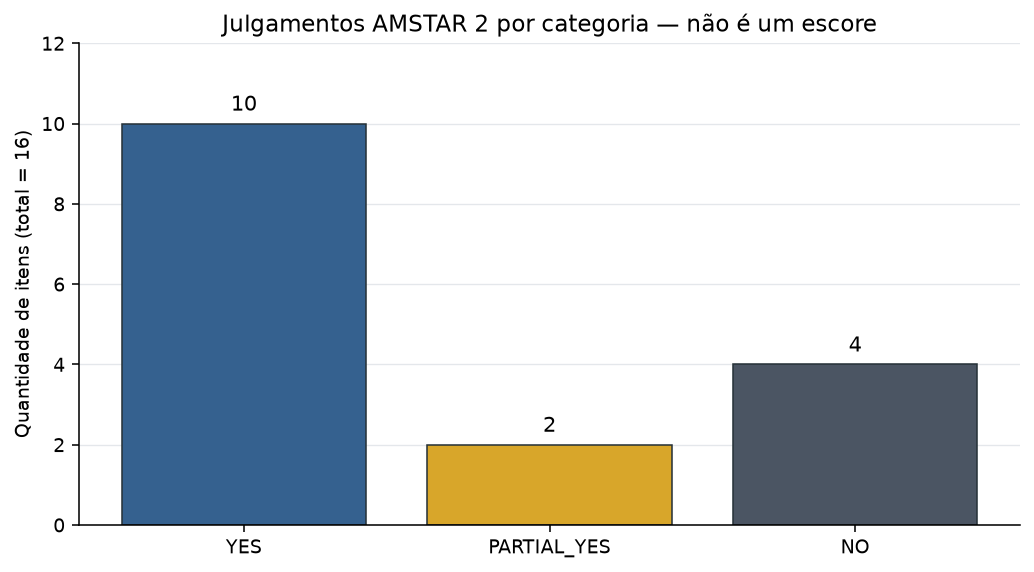

In [5]:
labels = ['YES', 'PARTIAL_YES', 'NO']
values = [rating_counts[label] for label in labels]
colors = ['#35618f', '#d8a62a', '#4b5563']
fig, ax = plt.subplots(figsize=(7.5, 4.2))
bars = ax.bar(labels, values, color=colors, edgecolor='#263238', linewidth=0.8)
ax.bar_label(bars, padding=4, fontsize=11)
ax.set_title('Julgamentos AMSTAR 2 por categoria — não é um escore')
ax.set_ylabel('Quantidade de itens (total = 16)')
ax.set_ylim(0, max(values) + 2)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', color='#d9dee3', linewidth=0.7, alpha=0.7)
ax.set_axisbelow(True)
plt.tight_layout()
buffer = BytesIO()
fig.savefig(buffer, format='png', dpi=140, bbox_inches='tight')
encoded_chart = base64.b64encode(buffer.getvalue()).decode('ascii')
display(HTML(
    '<img alt="Gráfico de barras com 10 itens YES, 2 PARTIAL_YES e 4 NO." '
    f'src="data:image/png;base64,{encoded_chart}" style="max-width:100%;">'
))
plt.close(fig)

## Checks

As verificações confirmam cobertura dos 16 itens, sete domínios críticos, proveniência, ausência de escore e propagação da confiança metodológica ao perfil usado pela síntese.

In [6]:
assert len(judgments) == 16
assert {item.item_id for item in AMSTAR2_ITEMS if item.critical} == {2, 4, 7, 9, 11, 13, 15}
assert all(judgment.evidence and judgment.section and judgment.source_url for judgment in judgments)
assert sum(rating_counts.values()) == 16
assert assessment.critical_flaws == (2, 4, 7, 9)
assert assessment.confidence is AmstarConfidence.CRITICALLY_LOW
assert assessment.single_reviewer
assert assessment.applicability_note
assert methodological_profile.level is QualityLevel.LOW
assert 'soma de pontos' in assessment.rationale

print(
    'Validação aprovada: 16 itens rastreáveis, 4 domínios críticos incompletos e '
    'confiança preliminar CRITICALLY_LOW, sem escore numérico.'
)

Validação aprovada: 16 itens rastreáveis, 4 domínios críticos incompletos e confiança preliminar CRITICALLY_LOW, sem escore numérico.


## Next Steps

A etapa estará validada quando todas as células forem executadas sem erros. Em uso real, um segundo revisor deverá conferir os julgamentos. A próxima etapa do MVP será incorporar esse perfil à síntese e gerar uma resposta explicável, separando sinal da evidência, confiança metodológica e limitações.